This notebook will introduce the energy-based perspective and define the corresponding hyperbolic / RBM energy formulation. It will analyze equilibrium behavior, energy decrease, stable states, and decision boundaries.

These formulas (Eq. 34, Eq. 40, Eq. 44) come from the HHNN paper and provide the theoretical basis of this notebook.

## Hyperbolic activation function (Eq. 34)

$$
g(z) = \frac{z}{|z|}
$$

## Energy function (Eq. 40)

Paper defines energy for HHNN (Eq. 40):

$$
E = \frac{1}{2} \sum_k \sum_{j \ne k} \overline{z_k} \, w_{kj} \, z_j
$$

## Energy gap (Eq. 44)

When neuron \(l\) changes state from \(z_l\) to \(z'_l\), the energy gap is (Eq. 44):

$$
\Delta E = (\overline{z'_l} I_l)_r - (\overline{z_l} I_l)_r
$$

where

$$
I_l = \sum_{j \ne l} w_{lj} z_j
$$

$$
(\cdot)_r \text{ is the real part}
$$

## Connection to Boltzmann equilibrium

Lower-energy states are more stable. In the HBM paper, the equilibrium distribution satisfies:

$$
p(z; w) \propto \exp(-H(z; w))
$$

which motivates analyzing energy decrease and stable states.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def resolve_project_paths():
    # Resolve project root regardless of where the notebook runs
    project_root = Path.cwd().resolve()
    if project_root.name == "notebooks":
        project_root = project_root.parent
    data_dir = project_root / "data"
    return project_root, data_dir


def load_movielens_sources(data_dir):
    ratings_path = data_dir / "rating.csv"
    if not ratings_path.exists():
        ratings_path = data_dir / "ratings.csv"

    scores_path = data_dir / "genome_scores.csv"
    if not scores_path.exists():
        raise FileNotFoundError("genome_scores.csv not found")

    movies_path = data_dir / "movies.csv"
    if not movies_path.exists():
        movies_path = data_dir / "movie.csv"
    if not movies_path.exists():
        raise FileNotFoundError("movies.csv (or movie.csv) not found")

    tag_path = data_dir / "tag.csv"
    if not tag_path.exists():
        tag_path = data_dir / "tags.csv"

    ratings_df = pd.read_csv(ratings_path, usecols=["movieId", "rating"])
    scores_df = pd.read_csv(scores_path, usecols=["movieId", "tagId", "relevance"])
    movies_df = pd.read_csv(movies_path, usecols=["movieId", "title", "genres"]).drop_duplicates("movieId")
    movies_df = movies_df.set_index("movieId")

    tag_df = pd.read_csv(tag_path) if tag_path.exists() else None
    return ratings_df, scores_df, movies_df, tag_df


def build_movie_sample(ratings_df, scores_df, movies_df, sample_n=200, random_state=42):
    # Select a common tagId to define hyperbolic states (x, y)
    tag_id = int(scores_df["tagId"].mode().iloc[0])
    score_slice = scores_df[scores_df["tagId"] == tag_id].set_index("movieId")

    movie_rating = ratings_df.groupby("movieId")["rating"].mean().rename("avg_rating")
    merged = movie_rating.to_frame().join(score_slice[["relevance"]], how="inner")
    merged = merged.sample(n=sample_n, random_state=random_state)

    movie_ids = merged.index.values
    movie_titles = movies_df.loc[movie_ids, "title"].tolist()

    return tag_id, merged, movie_ids, movie_titles


def build_hyperbolic_states(merged):
    # MovieLens-driven engineering construction of hyperbolic states (not a literal formula from the paper)
    x = (merged["avg_rating"] / 5.0).values + 0.1
    raw_y = merged["relevance"].values

    # rescale y so that x^2 > y^2
    scale = np.minimum(0.9 * np.abs(x) / (np.abs(raw_y) + 1e-8), 1.0)
    y = raw_y * scale
    modulus = np.sqrt(np.maximum(x**2 - y**2, 1e-12))

    # activation-like normalized state
    z_real = x / modulus
    z_unip = y / modulus
    return z_real, z_unip


def build_content_weight_matrix(scores_df, movies_df, movie_ids, top_tags=20):
    # MovieLens-driven engineering construction of content-based weights (not a literal formula from the paper)
    _top_tags = scores_df["tagId"].value_counts().head(top_tags).index.tolist()
    score_subset = scores_df[scores_df["tagId"].isin(_top_tags)]
    score_pivot = score_subset.pivot_table(index="movieId", columns="tagId", values="relevance", fill_value=0.0)

    score_pivot = score_pivot.loc[movie_ids]

    # Genres (content features)
    genres_series = movies_df.loc[movie_ids, "genres"].fillna("(no genres listed)")
    all_genres = sorted({g for gs in genres_series for g in str(gs).split("|")})
    genre_index = {g: i for i, g in enumerate(all_genres)}

    genre_matrix = np.zeros((len(movie_ids), len(all_genres)), dtype=float)
    for i, gs in enumerate(genres_series):
        for g in str(gs).split("|"):
            genre_matrix[i, genre_index[g]] = 1.0

    # Feature matrix = [genres one-hot | tag relevance]
    tag_matrix = score_pivot.values
    features = np.hstack([genre_matrix, tag_matrix])

    # Cosine similarity (symmetric weights)
    norm = np.linalg.norm(features, axis=1, keepdims=True)
    norm[norm == 0] = 1.0
    features_norm = features / norm
    W_real = features_norm @ features_norm.T

    # Hyperbolic view: keep unipotent part as zeros for this content-only matrix
    W_unip = np.zeros_like(W_real)

    return W_real, W_unip


project_root, data_dir = resolve_project_paths()
ratings_df, scores_df, movies_df, tag_df = load_movielens_sources(data_dir)

tag_id, merged, movie_ids, movie_titles = build_movie_sample(
    ratings_df, scores_df, movies_df, sample_n=200, random_state=42
)

z_real, z_unip = build_hyperbolic_states(merged)
W_real, W_unip = build_content_weight_matrix(scores_df, movies_df, movie_ids, top_tags=20)

print("project_root:", project_root)
print("data_dir:", data_dir)
print("tagId used:", tag_id)
print("sample count:", len(movie_ids))
print("movie_ids[0]:", movie_ids[0])
print("movie_titles[0]:", movie_titles[0])
print("z_real shape:", z_real.shape)
print("z_unip shape:", z_unip.shape)
print("W_real shape:", W_real.shape)
print("W_unip shape:", W_unip.shape)
print("userId used:", tag_df["userId"].iloc[0] if tag_df is not None else "(tag.csv missing)")
print("feedback_strength (from tag.csv):", 1.0 if tag_df is not None else "N/A")

# Optional tag feedback to define a state update for one movie
l = 0  # default index
feedback_strength = 0.0
if tag_df is not None:
    tag_df = tag_df[tag_df["movieId"].isin(movie_ids)]
    if not tag_df.empty:
        user_id = int(tag_df["userId"].value_counts().idxmax())
        user_tags = tag_df[tag_df["userId"] == user_id]
        movie_tag_counts = user_tags["movieId"].value_counts()
        l = int(np.where(movie_ids == movie_tag_counts.index[0])[0][0])
        max_count = movie_tag_counts.max()
        feedback_strength = float(movie_tag_counts.iloc[0] / max_count)
        print("userId used:", user_id)
        print("movieId updated:", int(movie_ids[l]))
        print("feedback_strength (from tag.csv):", round(feedback_strength, 3))
    else:
        print("tag.csv found but no overlap with sample movies; using default l=0")
else:
    print("tag.csv not found; using default l=0")

# Build z' for movie l using tag feedback (increase unipotent part slightly)

def adjust_unipotent(a, b, delta):
    b2 = b + delta
    scale = min(0.9 * abs(a) / (abs(b2) + 1e-8), 1.0)
    return b2 * scale

z_prime_real = z_real.copy()
z_prime_unip = z_unip.copy()
if feedback_strength > 0:
    delta = 0.3 * feedback_strength * abs(z_real[l])
    z_prime_unip[l] = adjust_unipotent(z_real[l], z_unip[l], delta)


project_root: /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys
data_dir: /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys/data
tagId used: 1
sample count: 200
movie_ids[0]: 63992
movie_titles[0]: Twilight (2008)
z_real shape: (200,)
z_unip shape: (200,)
W_real shape: (200, 200)
W_unip shape: (200, 200)
userId used: 18
feedback_strength (from tag.csv): 1.0
userId used: 88738
movieId updated: 3275
feedback_strength (from tag.csv): 1.0


In [2]:
# Compute energy and energy gap using hyperbolic states
# Use a small subset of movies as HHNN units
K = min(8, len(movie_ids))
idx = np.arange(K)

# Real-valued symmetric weights (movie-movie), unipotent part = 0
W_real_k = W_real[np.ix_(idx, idx)]
W_unip_k = W_unip[np.ix_(idx, idx)]

# Build z for the same K units
z_real_k = z_real[idx]
z_unip_k = z_unip[idx]


def hmul(a1, b1, a2, b2):
    """Hyperbolic multiply (a1 + u b1)(a2 + u b2)."""
    r = a1 * a2 + b1 * b2
    u = a1 * b2 + b1 * a2
    return r, u


def hconj(a, b):
    """Hyperbolic conjugate of (a + u b)."""
    return a, -b


def hreal_of_product_with_conjugate(a, b, c, d):
    """Real part of (conj(a+ub) * (c+ud))."""
    ar, au = hconj(a, b)
    r, _ = hmul(ar, au, c, d)
    return r


def compute_energy_eq40(z_real, z_unip, W_real, W_unip):
    """Energy (Eq. 40) real part using conjugate of z_k."""
    K = len(z_real)
    E_real = 0.0
    for k in range(K):
        for j in range(K):
            if j == k:
                continue
            a1, b1 = z_real[k], z_unip[k]
            a2, b2 = W_real[k, j], W_unip[k, j]
            a3, b3 = z_real[j], z_unip[j]
            r12, u12 = hmul(*hconj(a1, b1), a2, b2)
            r123, _ = hmul(r12, u12, a3, b3)
            E_real += r123
    return 0.5 * E_real


def compute_input_Il(l, z_real, z_unip, W_real, W_unip):
    """Input I_l = sum_{j != l} w_lj z_j (Eq. 39)."""
    I_real = 0.0
    I_unip = 0.0
    for j in range(len(z_real)):
        if j == l:
            continue
        a2, b2 = W_real[l, j], W_unip[l, j]
        a3, b3 = z_real[j], z_unip[j]
        r23, u23 = hmul(a2, b2, a3, b3)
        I_real += r23
        I_unip += u23
    return I_real, I_unip


def activation_eq34(i_real, i_unip):
    """Hyperbolic activation g(z) = z / |z| (Eq. 34)."""
    modulus = np.sqrt(np.maximum(i_real**2 - i_unip**2, 1e-12))
    return i_real / modulus, i_unip / modulus


def compute_delta_energy_eq44(l, z_real, z_unip, z_prime_real, z_prime_unip, W_real, W_unip):
    """Energy gap (Eq. 44) for neuron l."""
    I_real, I_unip = compute_input_Il(l, z_real, z_unip, W_real, W_unip)
    zI_r = hreal_of_product_with_conjugate(z_real[l], z_unip[l], I_real, I_unip)
    zIprime_r = hreal_of_product_with_conjugate(z_prime_real[l], z_prime_unip[l], I_real, I_unip)
    return zIprime_r - zI_r


# Energy (Eq. 40)
E_real = compute_energy_eq40(z_real_k, z_unip_k, W_real_k, W_unip_k)
print("Energy E (real part):", E_real)

# Energy gap (Eq. 44) using tag.csv-based state update
l_k = min(l, K - 1)
DeltaE = compute_delta_energy_eq44(
    l_k,
    z_real_k,
    z_unip_k,
    z_prime_real,
    z_prime_unip,
    W_real_k,
    W_unip_k,
)
print("Energy gap ΔE (real part):", DeltaE)

# Optional: check by recomputing energy with z' for l
z_real_k2 = z_real_k.copy()
z_unip_k2 = z_unip_k.copy()
z_real_k2[l_k] = z_prime_real[l_k]
z_unip_k2[l_k] = z_prime_unip[l_k]

E_real2 = compute_energy_eq40(z_real_k2, z_unip_k2, W_real_k, W_unip_k)
print("Energy E' (real part):", E_real2)
print("E' - E:", E_real2 - E_real)


Energy E (real part): 11.45857713736158
Energy gap ΔE (real part): 0.0
Energy E' (real part): 11.45857713736158
E' - E: 0.0


#### Visualization

We visualize the distribution of energy contributions and the energy gap for a small subset.

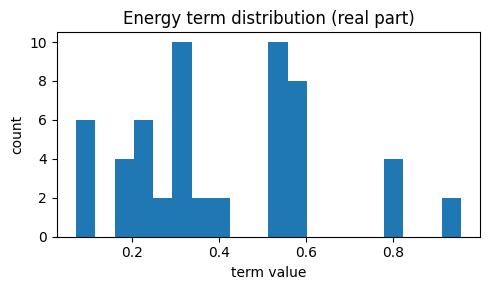

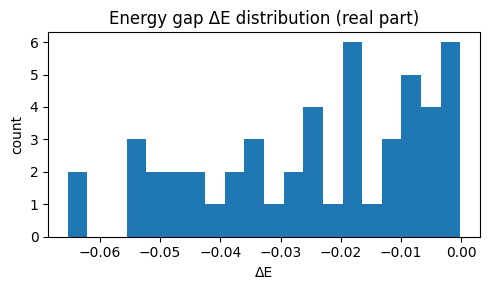

In [12]:
# Visualize energy contributions for each pair (k,j)
K = min(8, len(movie_ids))
idx = np.arange(K)

pair_terms = []
for k in range(K):
    for j in range(K):
        if j == k:
            continue
        # contribution to energy (real part) using conjugate
        a1, b1 = z_real_k[k], -z_unip_k[k]
        a2, b2 = W_real_k[k, j], W_unip_k[k, j]
        a3, b3 = z_real_k[j], z_unip_k[j]
        r12, u12 = hmul(a1, b1, a2, b2)
        r123, _ = hmul(r12, u12, a3, b3)
        pair_terms.append(r123)

plt.figure(figsize=(5, 3))
plt.hist(pair_terms, bins=20)
plt.title("Energy term distribution (real part)")
plt.xlabel("term value")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# Visualize energy gap for multiple random tag-based updates
np.random.seed(42)
energy_gaps = []
for l in np.random.choice(range(K), size=50, replace=True):
    I_real = 0.0
    I_unip = 0.0
    for j in range(K):
        if j == l:
            continue
        a2, b2 = W_real_k[l, j], W_unip_k[l, j]
        a3, b3 = z_real_k[j], z_unip_k[j]
        r23, u23 = hmul(a2, b2, a3, b3)
        I_real += r23
        I_unip += u23

    z_r, z_u = z_real_k[l], z_unip_k[l]
    # small random feedback strength (simulating tag feedback)
    fb = np.random.uniform(0.0, 1.0)
    delta = 0.3 * fb * abs(z_r)
    z_prime_u = adjust_unipotent(z_r, z_u, delta)

    zI_r = z_r * I_real - z_u * I_unip
    zIprime_r = z_r * I_real - z_prime_u * I_unip
    energy_gaps.append(zIprime_r - zI_r)

plt.figure(figsize=(5, 3))
plt.hist(energy_gaps, bins=20)
plt.title("Energy gap ΔE distribution (real part)")
plt.xlabel("ΔE")
plt.ylabel("count")
plt.tight_layout()
plt.show()

## Interpretation of results

- **Energy E (Eq. 40):** uses the conjugate \(\overline{z_k}\) to aggregate pairwise movie interactions. Lower energy indicates a more stable configuration.
- **Energy gap ΔE (Eq. 44):** we update one movie’s state using **tag.csv feedback** (simulating a user tagging a movie), then compute \(\Delta E\). If ΔE ≤ 0, the update does not increase energy, supporting convergence.
- **Histograms:** show the distribution of pairwise energy terms and ΔE values in the sampled subset, giving a stability and variability view.